# Credit Risk Analysis
## Goal: To predict which loan applicants are likely to default

#### Business problem:
A bank wants to identify high-risk borrowers before approving loans. We will analyze 150,000 loan applicants and build a model to predict default risk.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("../dataset/GiveMeSomeCredit-training.csv")

In [4]:
df.shape

(150000, 12)

In [5]:
df.columns.tolist()

['Unnamed: 0',
 'SeriousDlqin2yrs',
 'RevolvingUtilizationOfUnsecuredLines',
 'age',
 'NumberOfTime30-59DaysPastDueNotWorse',
 'DebtRatio',
 'MonthlyIncome',
 'NumberOfOpenCreditLinesAndLoans',
 'NumberOfTimes90DaysLate',
 'NumberRealEstateLoansOrLines',
 'NumberOfTime60-89DaysPastDueNotWorse',
 'NumberOfDependents']

In [6]:
df['Unnamed: 0'].head(10)

0     1
1     2
2     3
3     4
4     5
5     6
6     7
7     8
8     9
9    10
Name: Unnamed: 0, dtype: int64

In [7]:
df = df.drop(columns=['Unnamed: 0'])

In [8]:
df.shape

(150000, 11)

In [9]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtypes: float64(

### Missing values found
- Monthly Income: 29,731 missing (19.8% of data)
- NumberOfDependents: 3924 missing (2.6% of data)

Possible reasons for missing MonthlyIncome: self-employed, retired, or refused to disclose.
we will handle these in the data cleaning phase.

In [11]:
df.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [12]:
df.describe()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
count,150000.000000,150000.000000,150000.000000,150000.000000,150000.000000,1.202690e+05,150000.000000,150000.000000,150000.000000,150000.000000,146076.000000
mean,0.066840,6.048438,52.295207,0.421033,353.005076,6.670221e+03,8.452760,0.265973,1.018240,0.240387,0.757222
std,0.249746,249.755371,14.771866,4.192781,2037.818523,1.438467e+04,5.145951,4.169304,1.129771,4.155179,1.115086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.029867,41.000000,0.000000,0.175074,3.400000e+03,5.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.154181,52.000000,0.000000,0.366508,5.400000e+03,8.000000,0.000000,1.000000,0.000000,0.000000
75%,0.000000,0.559046,63.000000,0.000000,0.868254,8.249000e+03,11.000000,0.000000,2.000000,0.000000,1.000000
max,1.000000,50708.000000,109.000000,98.000000,329664.000000,3.008750e+06,58.000000,98.000000,54.000000,98.000000,20.000000


#### RevolvingUtilizationOfUnsecuredLines
- Ratio of credit card balance to total credit limit.
- If you owe 3000$ and your limit is 10,000, utilization = 0.3. 
- So logically, this should almost always be between 0 and 1 (maybe slightly above 1 if someone's over their limit).


It should decline a transaction that pushes you over your limit. But utilization going slightly over 1.0 in real data is actually more common than you'd expect, for a few real reasons:

Interest and fees accrue on top of the balance. If you're at your limit and get charged interest or a late fee, your balance can tick over the limit even with zero new purchases.  
Over-limit transactions do sometimes get approved — some banks/cards allow it (sometimes charging an over-limit fee), especially for existing customers or certain transaction types (recurring subscriptions, etc.), even though many now block it.  
Timing lag between reporting and reality. This dataset is built from credit bureau snapshots, not real-time bank data. Your credit limit could have been lowered by the bank (issuers do this to risky customers) after you already carried a balance — so your reported balance is now "over" a limit that changed after the fact.  
This ratio might combine multiple credit lines. "Unsecured lines" could mean it's aggregating several revolving accounts, and small reporting mismatches across accounts can push the combined ratio slightly over 1.

In [13]:
(df['RevolvingUtilizationOfUnsecuredLines'] > 1).sum()

np.int64(3321)

In [14]:
(df['RevolvingUtilizationOfUnsecuredLines'] > 2).sum()

np.int64(371)

In [15]:
(df['RevolvingUtilizationOfUnsecuredLines'] > 10).sum()

np.int64(241)

In [16]:
df['RevolvingUtilizationOfUnsecuredLines'].sort_values(ascending=False).head(10)

85489     50708.0
31414     29110.0
16956     22198.0
149160    22000.0
149279    20514.0
117315    18300.0
21978     17441.0
124533    13930.0
72592     13498.0
71705     13400.0
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

In [17]:
df[df['RevolvingUtilizationOfUnsecuredLines'] <= 1]['SeriousDlqin2yrs'].mean()

np.float64(0.05991996127598361)

In [18]:
df[df['RevolvingUtilizationOfUnsecuredLines'] > 1]['SeriousDlqin2yrs'].mean()

np.float64(0.3724781692261367)

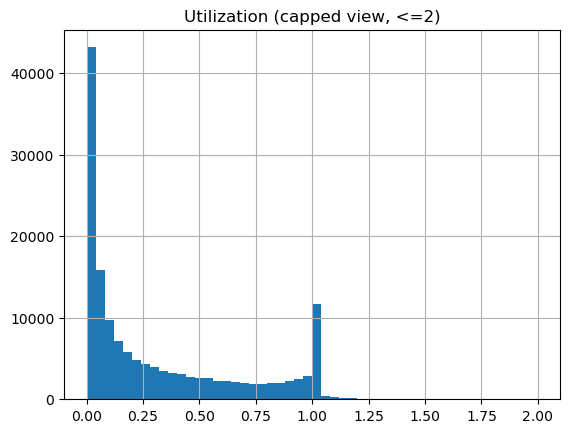

In [19]:
df[df['RevolvingUtilizationOfUnsecuredLines'] <= 2]['RevolvingUtilizationOfUnsecuredLines'].hist(bins=50)
plt.title('Utilization (capped view, <=2)')
plt.show()

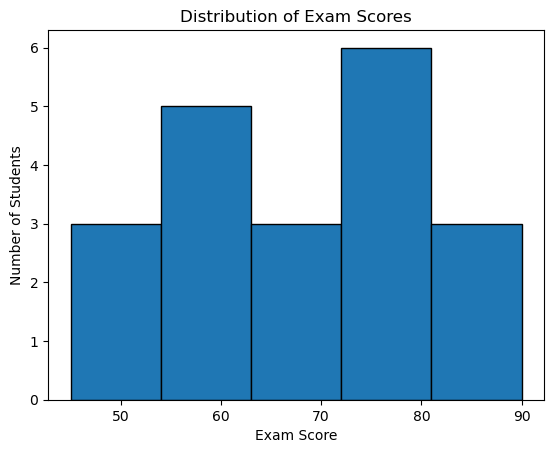

In [20]:

scores = [45, 50, 52, 55, 56, 60, 61, 62, 65, 67,
          70, 72, 73, 75, 76, 78, 80, 82, 85, 90]


plt.hist(scores, bins=5, edgecolor="black")

plt.xlabel("Exam Score")
plt.ylabel("Number of Students")
plt.title("Distribution of Exam Scores")

plt.show()

#### New column age

In [21]:
df['age'].describe()

count    150000.000000
mean         52.295207
std          14.771866
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

##### Age
step1: domain meaning<br>
Age of the borrower at the time of the credit report. Should be a realistic adult age. <br>
min:0<br>
max:109<br>
mean: 53.29<br>
median: 52<br>
mean and median are close, so the columns look roughly symmetric, not heavily skewed.

In [27]:
(df['age'] <18).sum()
#df[df['age']<18]

np.int64(1)

In [26]:
(df['age'] > 90).sum()
df[df["age"] > 90]['age'].value_counts().sort_index()

age
91     154
92      93
93      87
94      47
95      45
96      18
97      17
98       6
99       9
101      3
102      3
103      3
105      1
107      1
109      2
Name: count, dtype: int64

In [28]:
df.groupby(pd.cut(df['age'], bins= [0,25,35,45,55,65,75,110]))['SeriousDlqin2yrs'].mean()

age
(0, 25]      0.111662
(25, 35]     0.111225
(35, 45]     0.088132
(45, 55]     0.075933
(55, 65]     0.045830
(65, 75]     0.026151
(75, 110]    0.020436
Name: SeriousDlqin2yrs, dtype: float64

### Conclusion

One bad value (age=0) → fix in cleaning (drop row or impute with median)<br>
Otherwise clean, no capping needed<br>
Strong, monotonic negative relationship with default risk — confirmed useful predictor<br>

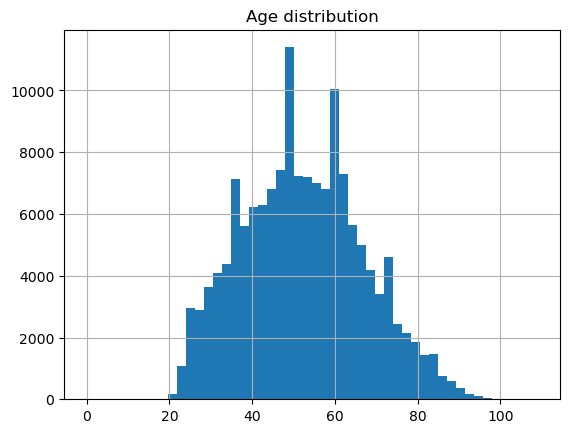

In [29]:
df['age'].hist(bins=50)
plt.title("Age distribution")
plt.show()

### Debt Ratio

Debt ration is monthly debt payments divided by monthly income

In [30]:
df['DebtRatio'].describe()

count    150000.000000
mean        353.005076
std        2037.818523
min           0.000000
25%           0.175074
50%           0.366508
75%           0.868254
max      329664.000000
Name: DebtRatio, dtype: float64

### Explanation:
Mean is 353 and median is 0.36. This tells us the same story as utilization: a small number of extreme outliers are dragging the mean way up, while the Typical person has a perfectly reasonable DebtRation (0.366 meaning, 37% of income to debt.) This is huge red flag for outliers, even bigger than what we saw in utilization.

In [33]:
(df['DebtRatio'] > 2).sum()

np.int64(31045)

In [34]:
(df['DebtRatio'] > 10).sum()

np.int64(28877)

In [35]:
(df['DebtRatio'] > 100).sum()

np.int64(24380)

In [36]:
df['DebtRatio'].sort_values(ascending=False).head(10)

60152     329664.0
36600     326442.0
127047    307001.0
58900     220516.0
4854      168835.0
7513      110952.0
103041    106885.0
69845     101320.0
66785      61907.0
53682      61106.5
Name: DebtRatio, dtype: float64

In [37]:
df['MonthlyIncome'].isnull().sum()

np.int64(29731)

In [38]:
df[df['DebtRatio'] > 1]['MonthlyIncome'].isnull().sum()

np.int64(27904)

In [39]:
df[df['DebtRatio'] <= 1]['MonthlyIncome'].isnull().sum()

np.int64(1827)

In [40]:
df[df['DebtRatio'] <= 1]['SeriousDlqin2yrs'].mean()

np.float64(0.06734109330245597)

In [41]:
df[df['DebtRatio'] > 1]['SeriousDlqin2yrs'].mean()

np.float64(0.06520192389788541)

### Conclusion
- Represents debt to income ratio, should be typically be well under 1-2 normal cases
- ~20% of rows have DebtRation > 1, but this is driven almost entirely (94%) by rows with missing MonthlyIncome
- Unlike utlization, these extreme values carry no additional predictive signal confirmed via near identical default rates
- Decision: dont try to fix DebtRatio in isolation. Handle it as a downstream consequence of the MonthlyIncome missing value problem, once we decide how to impute income, we'll revisit whether DebtRation needs recalculating or whether a simpler approach (like capping at a reasonable value eg:2 or 3) is good enough.
- Worth carrying forward the idea of a MonthlyIncome_missing flag as its own feature, to  test later if "not reporting income" itself predicts anything.

### MonthlyIncome
Borrower's self reported monthly income.

In [42]:
df['MonthlyIncome'].describe()

count    1.202690e+05
mean     6.670221e+03
std      1.438467e+04
min      0.000000e+00
25%      3.400000e+03
50%      5.400000e+03
75%      8.249000e+03
max      3.008750e+06
Name: MonthlyIncome, dtype: float64

In [43]:
df['MonthlyIncome'].isnull().sum()

np.int64(29731)

In [44]:
(df['MonthlyIncome'] == 0).sum()

np.int64(1634)

In [45]:
df['MonthlyIncome'].sort_values(ascending=False).head(10)

73763     3008750.0
137140    1794060.0
111365    1560100.0
50640     1072500.0
122543     835040.0
123291     730483.0
93564      702500.0
96549      699530.0
119136     649587.0
37078      629000.0
Name: MonthlyIncome, dtype: float64

In [46]:
df['MonthlyIncome'].quantile([0.5,0.9,0.95,0.99,0.999])

0.500     5400.000
0.900    11666.000
0.950    14587.600
0.990    25000.000
0.999    78395.748
Name: MonthlyIncome, dtype: float64

In [47]:
df['MonthlyIncome_missing'] = df['MonthlyIncome'].isnull()

In [48]:
df.groupby('MonthlyIncome_missing')['SeriousDlqin2yrs'].mean()

MonthlyIncome_missing
False    0.069486
True     0.056137
Name: SeriousDlqin2yrs, dtype: float64

In [49]:
df.groupby('MonthlyIncome_missing')['age'].mean()

MonthlyIncome_missing
False    51.289792
True     56.362349
Name: age, dtype: float64

In [50]:
df.groupby('MonthlyIncome_missing')['DebtRatio'].median()

MonthlyIncome_missing
False       0.296023
True     1159.000000
Name: DebtRatio, dtype: float64

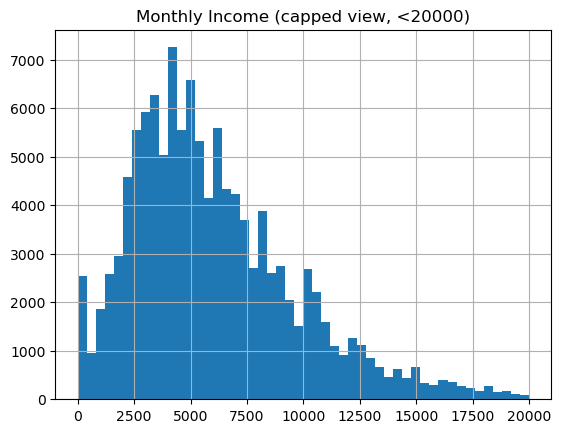

In [51]:
df[df['MonthlyIncome'] < 20000]['MonthlyIncome'].hist(bins=50)
plt.title('Monthly Income (capped view, <20000)')
plt.show()

### Number of Times xxxx Days Late
How many times the borrower was late on a payment by that many days

In [52]:
df['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index()

NumberOfTime30-59DaysPastDueNotWorse
0     126018
1      16033
2       4598
3       1754
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       264
Name: count, dtype: int64

In [53]:
df['NumberOfTime60-89DaysPastDueNotWorse'].value_counts().sort_index()

NumberOfTime60-89DaysPastDueNotWorse
0     142396
1       5731
2       1118
3        318
4        105
5         34
6         16
7          9
8          2
9          1
11         1
96         5
98       264
Name: count, dtype: int64

In [55]:
df['NumberOfTimes90DaysLate'].value_counts().sort_index()

NumberOfTimes90DaysLate
0     141662
1       5243
2       1555
3        667
4        291
5        131
6         80
7         38
8         21
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       264
Name: count, dtype: int64

In [57]:
mask_96_98 = (df['NumberOfTime30-59DaysPastDueNotWorse'].isin([96,98]))
df[mask_96_98][['NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate']].drop_duplicates()

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
1733,98,98,98
41944,96,96,96


In [58]:
df[mask_96_98]['SeriousDlqin2yrs'].mean()

np.float64(0.5464684014869888)

In [59]:
df[~mask_96_98]['SeriousDlqin2yrs'].mean()

np.float64(0.06597832112254644)

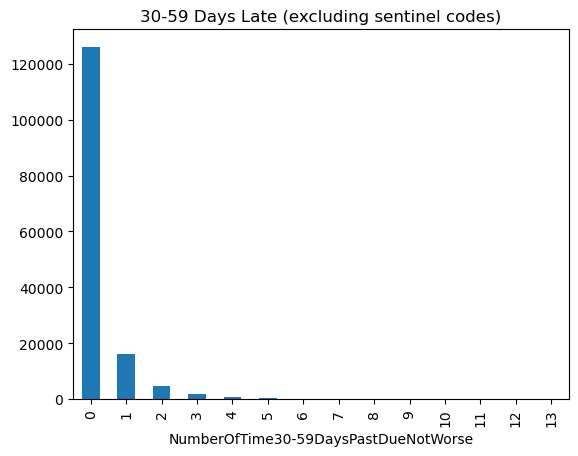

In [60]:
df[~mask_96_98]['NumberOfTime30-59DaysPastDueNotWorse'].value_counts().sort_index().plot(kind='bar')
plt.title('30-59 Days Late (excluding sentinel codes)')
plt.show()

#### Summary:

- All three share an identical sentinel code issue: 96 (5 rows) and 98 (264 rows), always appearing together across all three columns for the same rows
- These 269 rows have a ~55% default rate vs ~6.6% for everyone else — extremely strong signal, not noise
- Plan: create a has_sentinel_delinquency flag, replace 96/98 with a sensible placeholder (e.g., 0 or median) in the original columns
- The "normal" values (0 through low teens) show a clean, expected decaying distribution — no further issues

In [61]:
df[['NumberOfOpenCreditLinesAndLoans', 'NumberRealEstateLoansOrLines', 'NumberOfDependents']].describe()

,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,NumberOfDependents
count,150000.000000,150000.000000,146076.000000
mean,8.452760,1.018240,0.757222
std,5.145951,1.129771,1.115086
min,0.000000,0.000000,0.000000
25%,5.000000,0.000000,0.000000
50%,8.000000,1.000000,0.000000
75%,11.000000,2.000000,1.000000
max,58.000000,54.000000,20.000000


In [62]:
df['NumberRealEstateLoansOrLines'].value_counts().sort_index()

NumberRealEstateLoansOrLines
0     56188
1     52338
2     31522
3      6300
4      2170
5       689
6       320
7       171
8        93
9        78
10       37
11       23
12       18
13       15
14        7
15        7
16        4
17        4
18        2
19        2
20        2
21        1
23        2
25        3
26        1
29        1
32        1
54        1
Name: count, dtype: int64

In [63]:
df['NumberOfDependents'].isnull().sum()

np.int64(3924)

In [64]:
df.groupby(df['NumberOfDependents'].isnull())['SeriousDlqin2yrs'].mean()

NumberOfDependents
False    0.067410
True     0.045617
Name: SeriousDlqin2yrs, dtype: float64

In [65]:
df.groupby(pd.cut(df['NumberOfOpenCreditLinesAndLoans'], bins=[0,3,6,9,12,15,20,60]))['SeriousDlqin2yrs'].mean()

NumberOfOpenCreditLinesAndLoans
(0, 3]      0.093046
(3, 6]      0.060701
(6, 9]      0.054276
(9, 12]     0.059599
(12, 15]    0.064295
(15, 20]    0.068657
(20, 60]    0.070101
Name: SeriousDlqin2yrs, dtype: float64

In [66]:
df.groupby(pd.cut(df['NumberRealEstateLoansOrLines'], bins=[-1,0,1,2,3,5,10,60]))['SeriousDlqin2yrs'].mean()

NumberRealEstateLoansOrLines
(-1, 0]     0.083149
(0, 1]      0.052505
(1, 2]      0.055993
(2, 3]      0.066984
(3, 5]      0.096887
(5, 10]     0.173104
(10, 60]    0.223404
Name: SeriousDlqin2yrs, dtype: float64

### Correlation Check
Lets see how the features relate to each other, this matters because highly correlated features can cause redundancy (especially for linear models like logistic regression), and it's also a nice way to double check some of the relationships we already found.

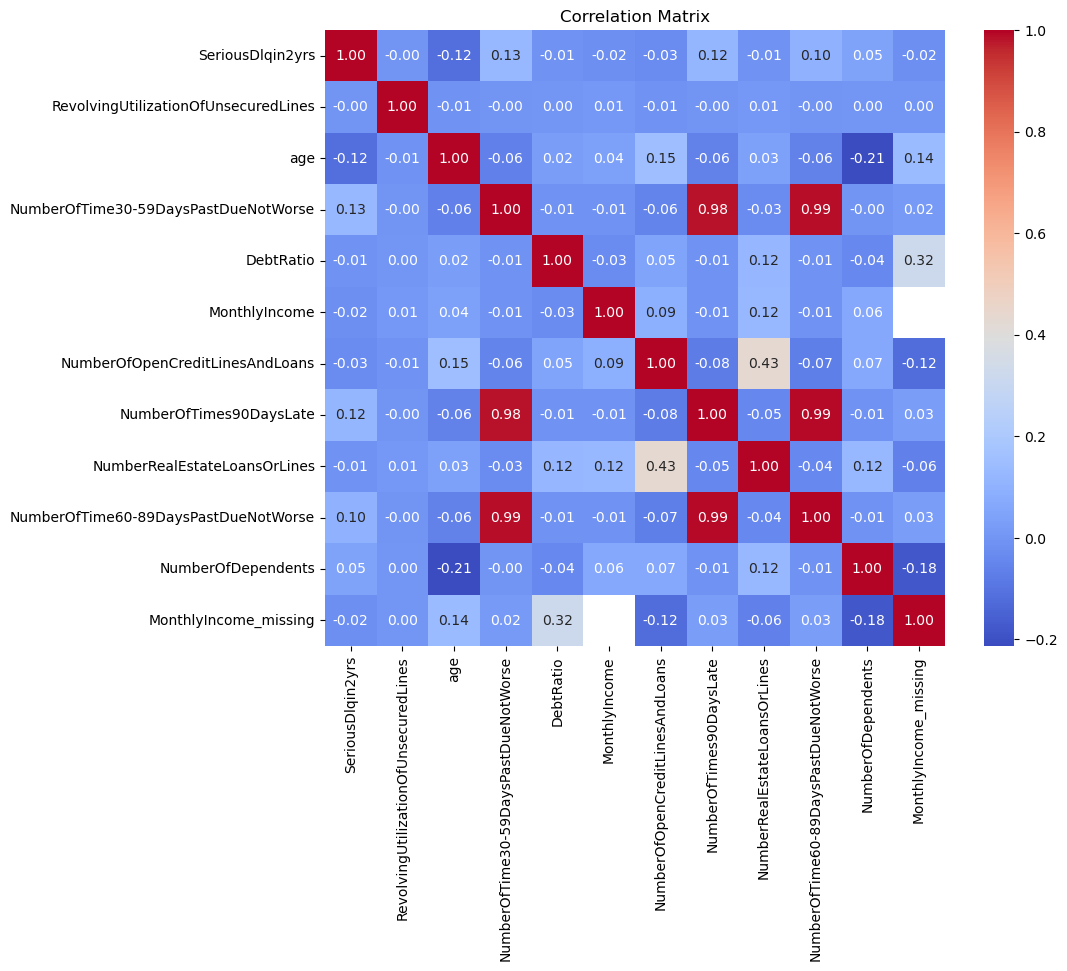

In [67]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop(columns=['Unnamed:0'], errors='ignore').corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [68]:
df[~mask_96_98][['NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate']].corr()

,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate
NumberOfTime30-59DaysPastDueNotWorse,1.000000,0.305876,0.218147
NumberOfTime60-89DaysPastDueNotWorse,0.305876,1.000000,0.294638
NumberOfTimes90DaysLate,0.218147,0.294638,1.000000


In [46]:
3321/150000

0.02214

# Describing the findings

When looking at the max values:
- NumberOfTimes90DaysLate = 98, means 98 times late on payments. That's being late every month for 8 years straight. Almost certainly a data entry error or outlier.
- RevolvingUtilizationOfUnsecuredLines = 50708, this is the ratio (how much credit limit are you using? a ratio should be between 0 and 1. Someone using 50,708% of their credit limit is impossible. This is a dirty data problem.)
- This is called outlier detection.

In [13]:
df['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

### Insight:

This is a problem. And an important one.
Think about it — if our ML model is lazy and just predicts "nobody defaults" for everyone, it would be 93.3% accurate. Sounds great right?
But it would miss every single actual defaulter. Completely useless for a bank.
This is called a Class Imbalance problem. We'll deal with it in the ML phase. But spotting it now — during EDA — means we won't be surprised later.

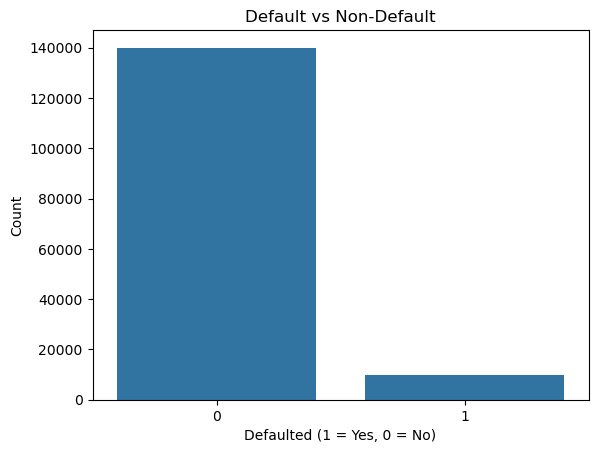

In [15]:
sns.countplot(x='SeriousDlqin2yrs', data =df)
plt.title('Default vs Non-Default')
plt.xlabel('Defaulted (1 = Yes, 0 = No)')
plt.ylabel('Count')
plt.show()


##### from the above figure, we can see that default value = 1 is significantly less than default value = 0.

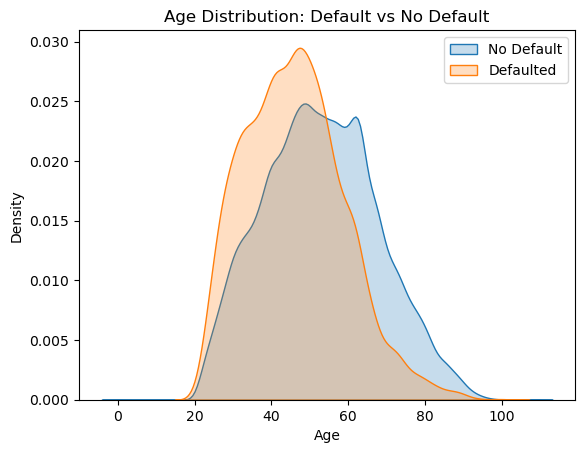

In [17]:
sns.kdeplot(data=df[df['SeriousDlqin2yrs']==0]['age'], label='No Default', fill=True)
sns.kdeplot(data=df[df['SeriousDlqin2yrs']==1]['age'], label='Defaulted', fill=True)
plt.title('Age Distribution: Default vs No Default')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

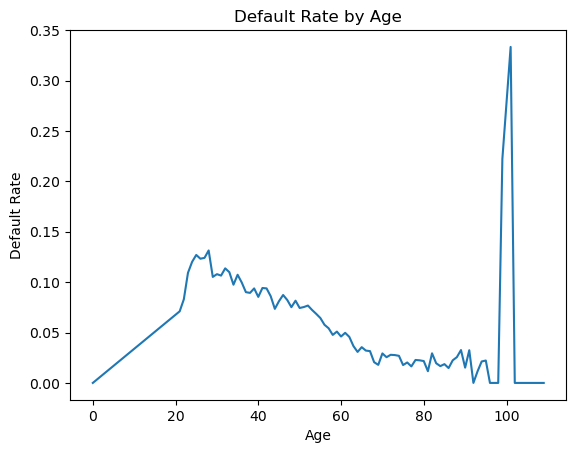

In [18]:
df.groupby('age')['SeriousDlqin2yrs'].mean().plot()
plt.title('Default Rate by Age')
plt.xlabel('Age')
plt.ylabel('Default Rate')
plt.show()

### age vs default rate:
- visualization created but needs further interpretation
- to revisit: understand  KDE plots and density

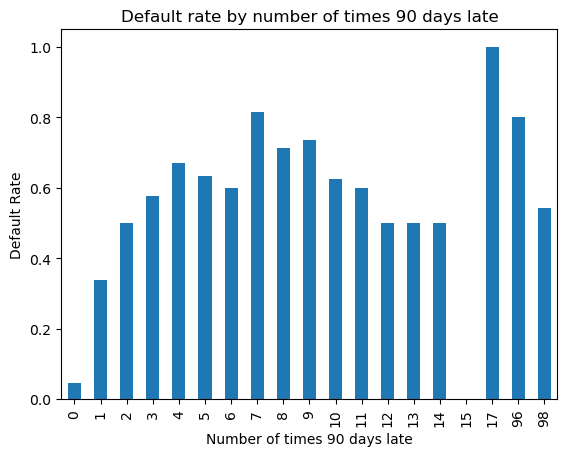

In [20]:
df.groupby('NumberOfTimes90DaysLate')['SeriousDlqin2yrs'].mean().plot(kind='bar')
plt.title('Default rate by number of times 90 days late')
plt.xlabel('Number of times 90 days late')
plt.ylabel('Default Rate')
plt.show()